In [ ]:
import pyodbc
from flask import Flask, jsonify, request
from cassandra.cluster import Cluster
from cassandra.query import SimpleStatement
from pymongo import MongoClient
from bson import ObjectId
from datetime import datetime, timedelta

app = Flask(__name__)

#Variables para conectarse a mongodb
client = MongoClient("mongodb://localhost:27017/")
db = client["uber"]

#Metodo para pasar de obj a string
def objectid_to_str(obj):
    if isinstance(obj, ObjectId):
        return str(obj)
    raise TypeError(f"Object of type {obj} is not serializable")

#Conexion con SQL
def get_db_connection():
    conn = pyodbc.connect(
        'DRIVER={ODBC Driver 17 for SQL Server};'
        'SERVER=.;'
        'DATABASE=Practicas;'
        'Trusted_Connection=yes;'
    )
    return conn

#Conexion con cassandra
def get_cassandra_connection():
    cluster = Cluster(['localhost'], port=9042)
    session = cluster.connect()
    session.set_keyspace('cassandratp')
    return session

In [ ]:
#Cassandra: ¿Cuantos autos con terminacion de patente en “D” y de Marca Toyota hay en la plataforma? 
@app.route('/cassandra/cars/toyota', methods=['GET'])
def cassandra_obtener_autos_toyota():
    session = get_cassandra_connection()

    query = SimpleStatement("""SELECT id_vehiculo, modelo, patente FROM Vehiculos                                                                                    
                                 WHERE marca = 'Toyota' AND ultima_letra_patente = 'D';""")
    rows = session.execute(query)

    reseñas = []
    for row in rows:
        reseñas.append({
            'id_vehiculo': row.id_vehiculo,
            'modelo': row.modelo,
            'patente': row.patente
        })

    return jsonify(reseñas)

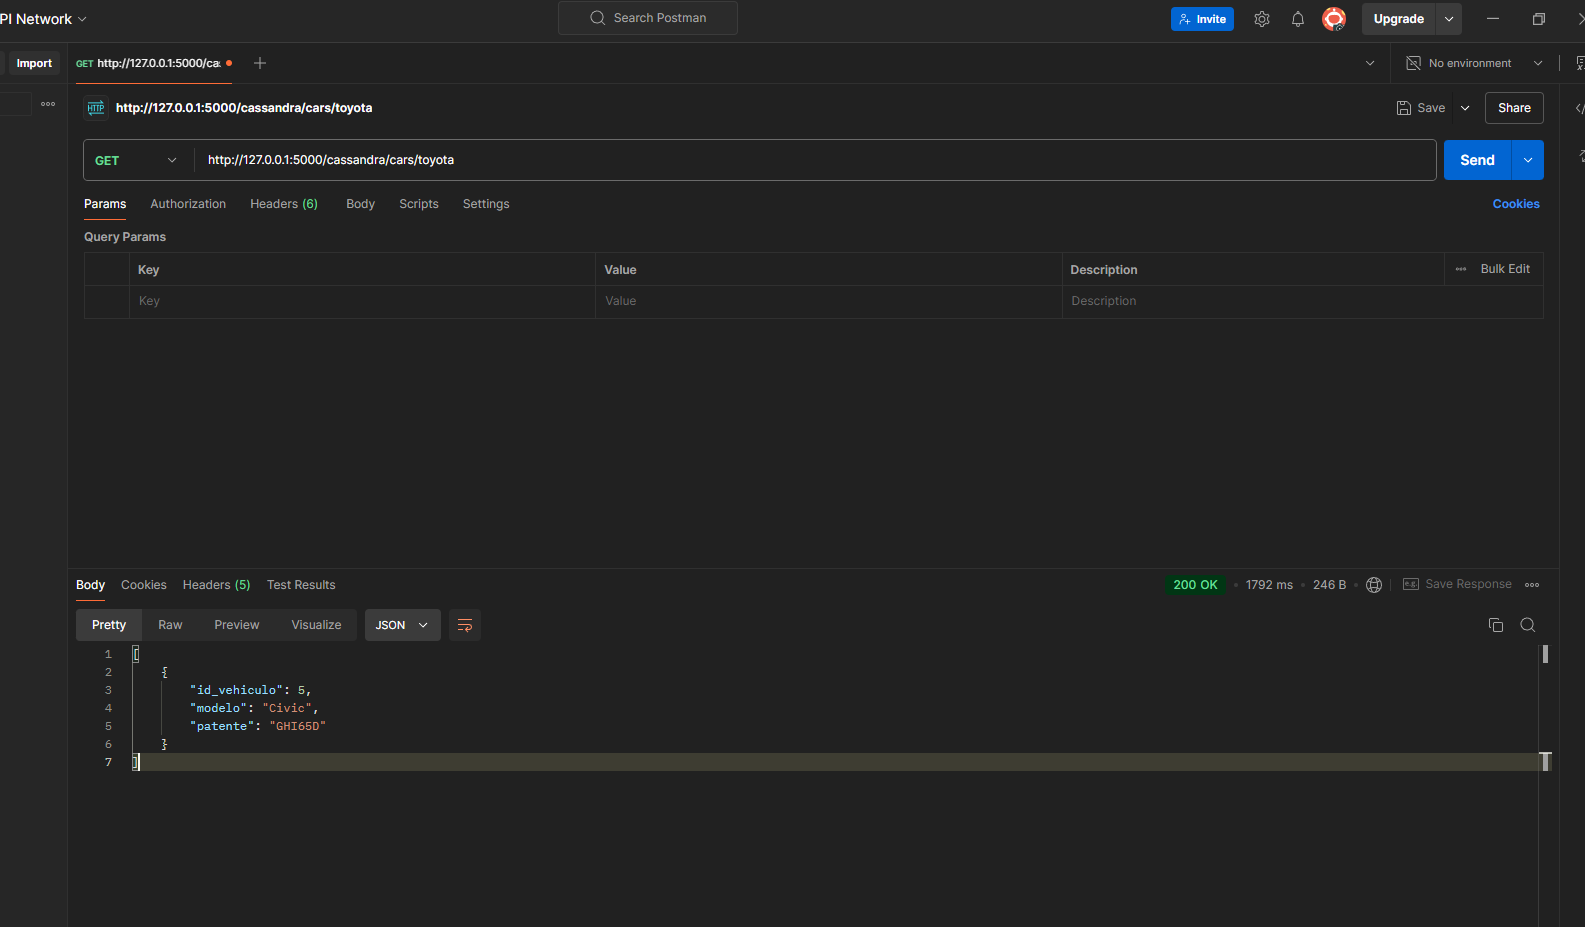

NOTA: somos concientes de que el Civic es Honda, pero en los inserts cometimos un pequeño error y quedo con marca Toyota.

In [ ]:
#Endpoints mongo

#¿Cual es el top 3 de usuarios que han dado mas reseñas? 
@app.route('/mongo/users/top3', methods=['GET'])
def mongo_obtener_top_usuarios():
    pipeline = [
        {"$project": {"nombre": 1, "apellido": 1, "email": 1, "cantidad_reseñas": {"$size": "$reseñasDadas"}}},
        {"$sort": {"cantidad_reseñas": -1}},
        {"$limit": 3}
    ]
    usuarios = list(db.usuarios.aggregate(pipeline))
    for usuario in usuarios:
        usuario["_id"] = objectid_to_str(usuario["_id"])
    
    return jsonify(usuarios)


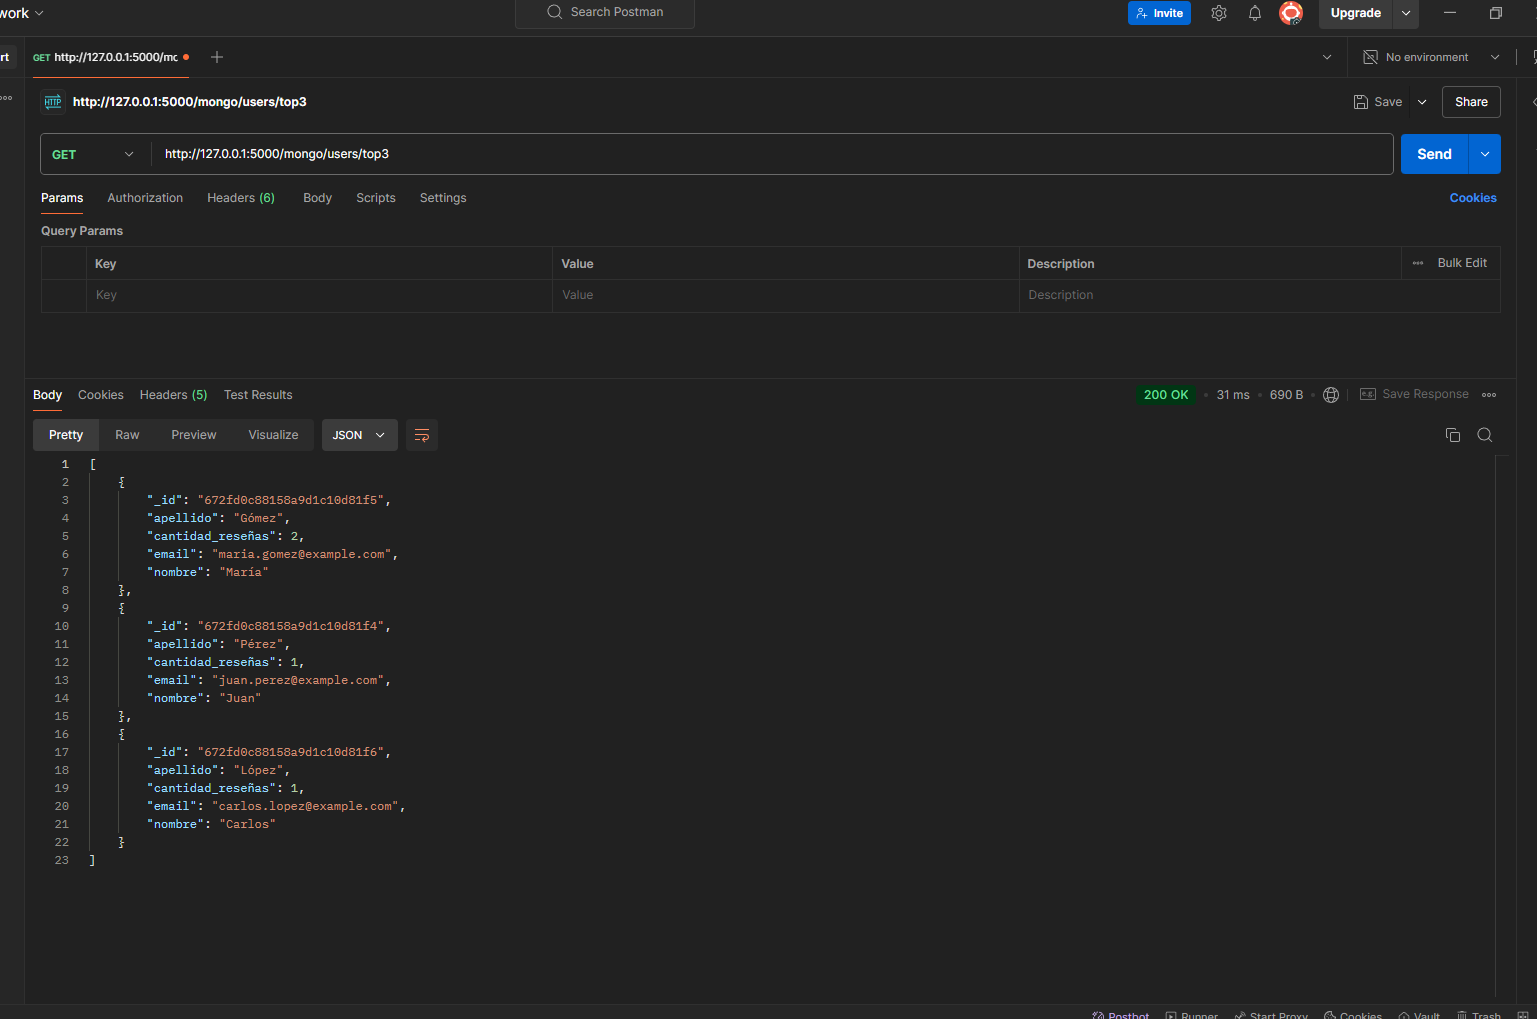


In [ ]:
#¿Cual es el metodo de pago menos utilizado en la plataforma?
@app.route('/mongo/pay-method/lessused', methods=['GET'])
def mongo_obtener_metodo_pago_menos_utilizado():
    pipeline = [
        {"$unwind": "$pagos"},
        {"$group": {"_id": "$pagos.metodoDePago", "cantidad": {"$sum": 1}}},
        {"$sort": {"cantidad": 1}},
        {"$limit": 1}
    ]
    resultado = list(db.usuarios.aggregate(pipeline))
    return jsonify(resultado)

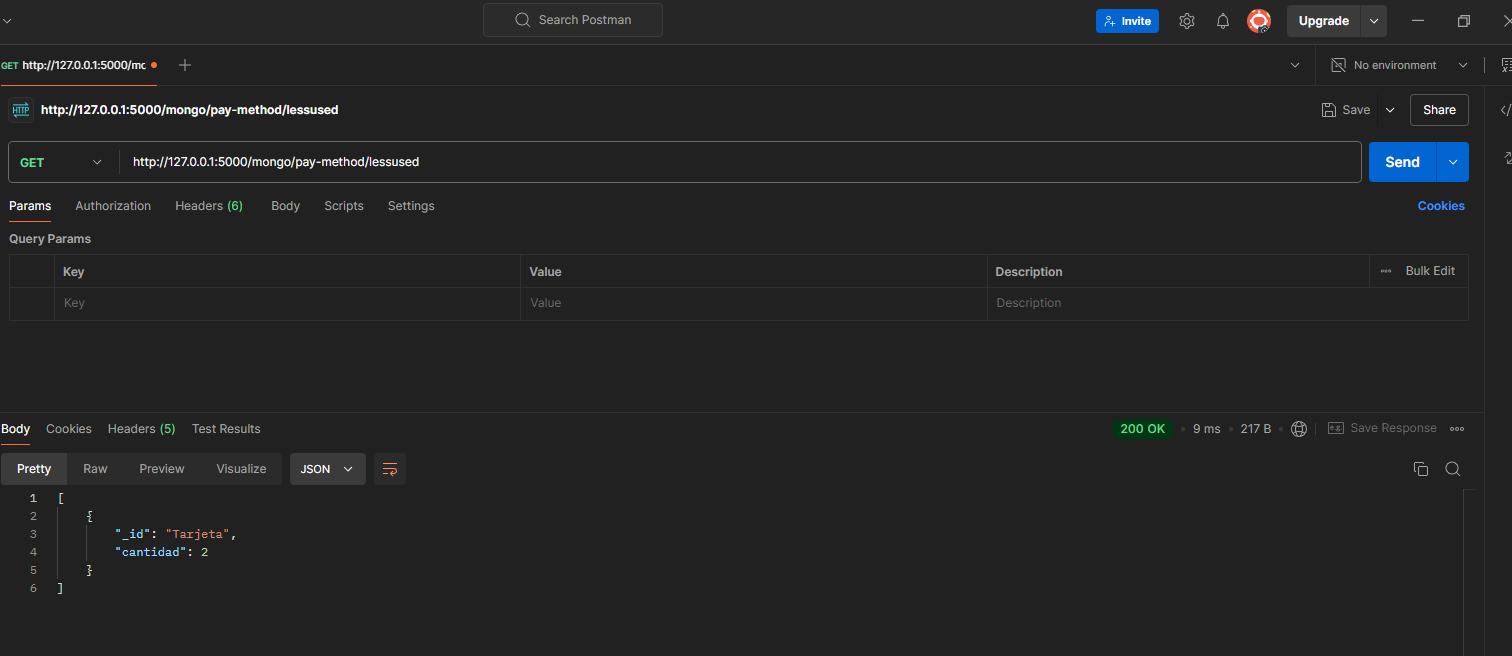

In [ ]:
#¿Cuales son los conductores que han estado inactivos en el ultimo mes? 
@app.route('/mongo/drivers/inactive', methods=['GET'])
def mongo_obtener_conductores_inactivos():
    fecha_limite = datetime.now() - timedelta(days=30)
    pipeline = [
        {"$match": {"ultima_actividad": {"$lt": fecha_limite}}},
        {"$project": {"nombre": 1, "apellido": 1, "ultima_actividad": 1}}
    ]
    conductores_inactivos = list(db.conductores.aggregate(pipeline))

    for conductor in conductores_inactivos:
        conductor["_id"]= objectid_to_str(conductor["_id"])

    return jsonify(conductores_inactivos)

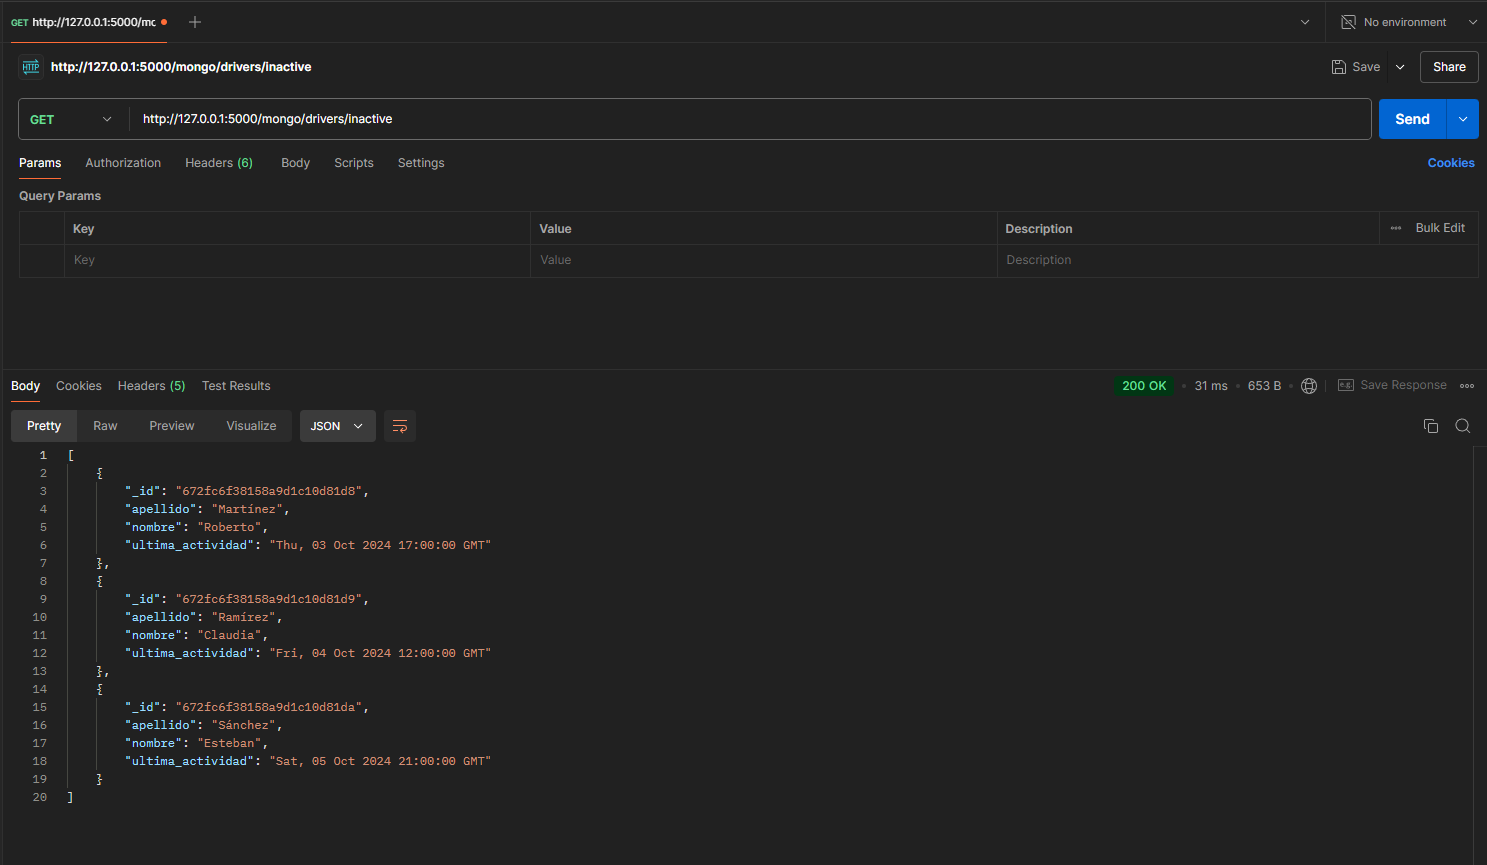

In [ ]:
#¿Que conductores y pasajeros han coincidido en mas de 1 viaje en la aplicacion? 
@app.route('/mongo/coincidencias', methods=['GET'])
def mongo_obtener_viajes_comunes():
    pipeline = [
        {"$lookup": {
            "from": "usuarios", 
            "localField": "_id",
            "foreignField": "reseñasDadas.id_viaje",
            "as": "pasajeros"
        }},
        
        {"$unwind": "$pasajeros"}, 
        {"$group": {
            "_id": {
                "conductor": "$id_conductor", 
                "pasajero": "$pasajeros._id" 
            },
            "viajes_comunes": {"$sum": 1} 
        }},
        
        {"$match": {"viajes_comunes": {"$gt": 1}}},
        
        {"$lookup": {
            "from": "conductores", 
            "localField": "_id.conductor",
            "foreignField": "_id",
            "as": "conductor_info"
        }},
        
        {"$lookup": {
            "from": "usuarios",
            "localField": "_id.pasajero",
            "foreignField": "_id",
            "as": "pasajero_info"
        }},
        
        {"$project": {
            "conductor": {"$arrayElemAt": ["$conductor_info.nombre", 0]},  
            "pasajero": {"$arrayElemAt": ["$pasajero_info.nombre", 0]}, 
            "viajes_comunes": 1  
        }}
    ]
    

    coincidencias = list(db.viajes.aggregate(pipeline))
    
    for coincidencia in coincidencias:
        if "_id" in coincidencia and "conductor" in coincidencia["_id"]:
            coincidencia["_id"]["conductor"] = objectid_to_str(coincidencia["_id"]["conductor"])
        if "_id" in coincidencia and "pasajero" in coincidencia["_id"]:
            coincidencia["_id"]["pasajero"] = objectid_to_str(coincidencia["_id"]["pasajero"])

    return jsonify(coincidencias)

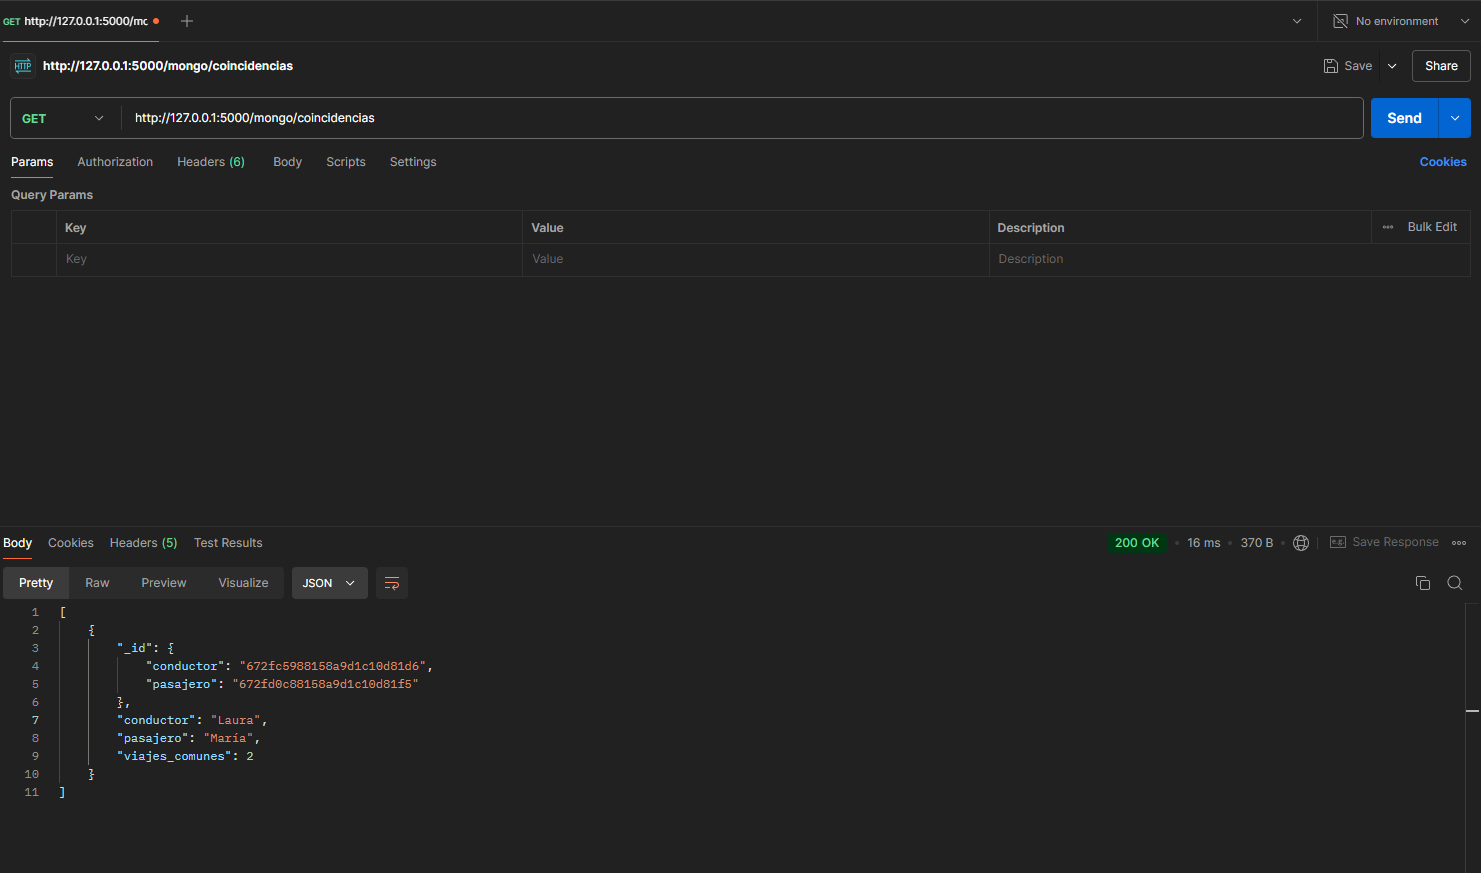

In [ ]:
#¿Cuales son los usuarios que han dado una calificacion de 5 o una calificacion menor de 2? 
@app.route('/mongo/users/stars', methods=['GET'])
def mongo_obtener_usuarios_calificaciones():
    pipeline = [
        {"$unwind": "$reseñasDadas"},
        {"$match": {"$or": [{"reseñasDadas.calificacion": 5}, {"reseñasDadas.calificacion": {"$lte": 2}}]}},
        {"$project": {"nombre": 1, "apellido": 1, "email": 1, "reseñasDadas.calificacion": 1}}
    ]
    usuarios = list(db.usuarios.aggregate(pipeline))

    for usuario in usuarios:
        usuario["_id"] = objectid_to_str(usuario["_id"])
    
    return jsonify(usuarios)

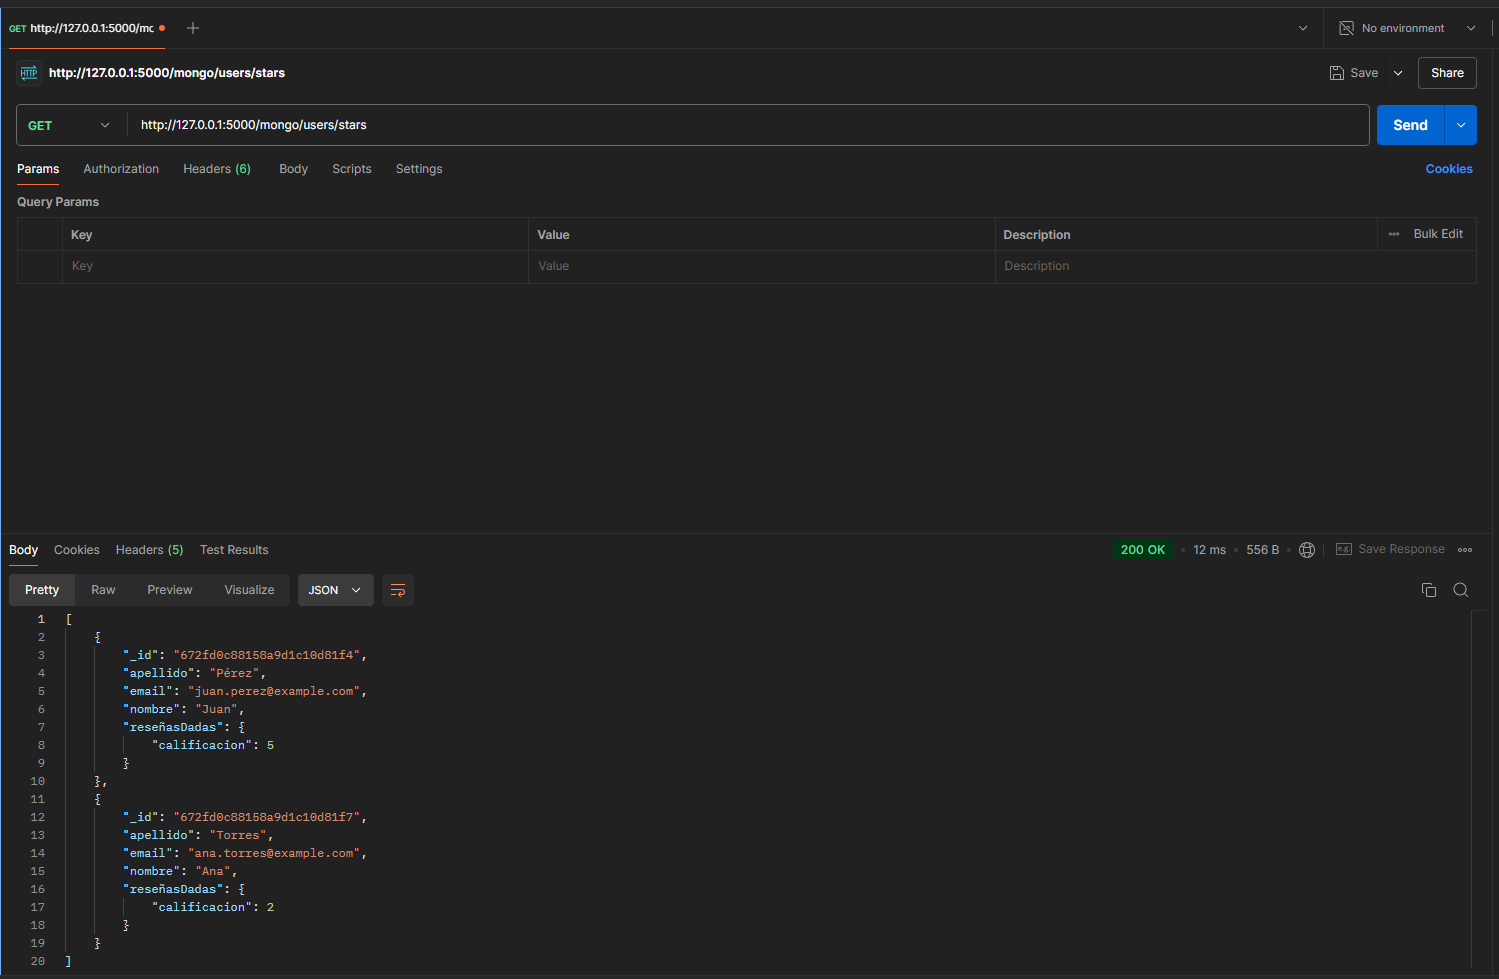

In [ ]:
#¿Cual es el tiempo promedio de los viajes? 
@app.route('/mongo/travels/avgtime', methods=['GET'])
def mongo_obtener_tiempo_promedio():
    pipeline = [
        {"$group": {"_id": None, "tiempo_promedio": {"$avg": "$tiempo_viaje"}}}
    ]
    resultado = list(db.viajes.aggregate(pipeline))
    return jsonify(resultado)

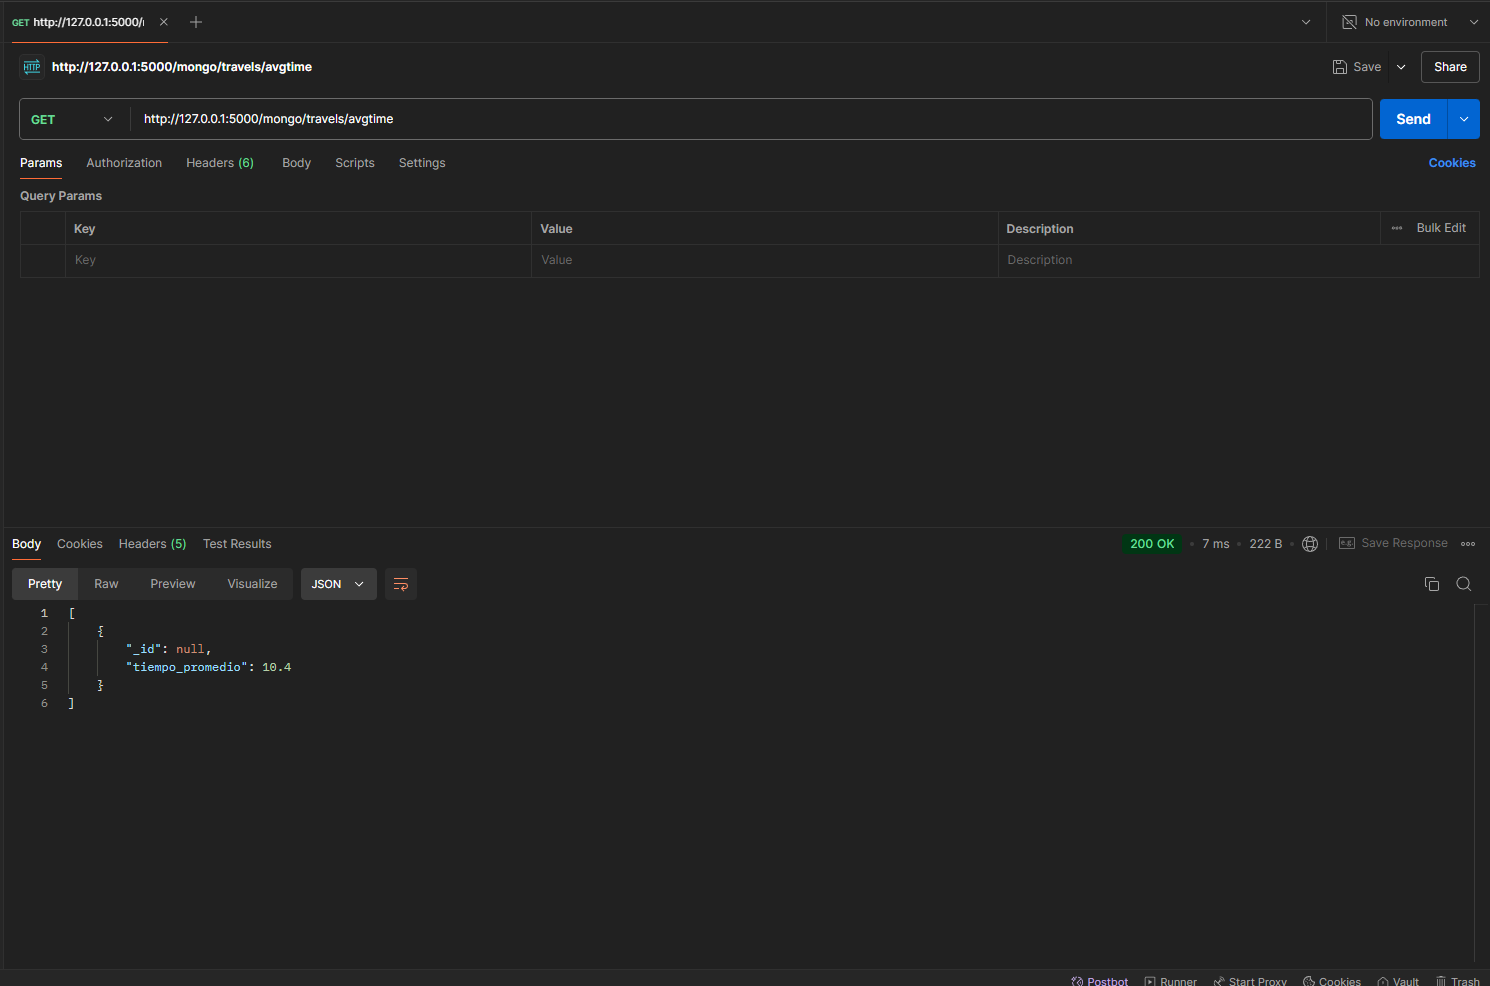

In [ ]:
#Endpoints para SQL

#¿Cual es el top 3 de usuarios que han dado mas reseñas? 
@app.route('/users/top3', methods=['GET'])
def obtener_top_usuarios():
    conn = get_db_connection()
    cursor = conn.cursor()

    cursor.execute("""SELECT TOP 3 id_usuario, COUNT(*) AS total_reseñas
                        FROM Reseña
                        GROUP BY id_usuario
                        ORDER BY total_reseñas DESC;
                        """)
    rows = cursor.fetchall()


    items = []
    for row in rows:
        items.append({"id_usuario": row[0], "total_resenia": row[1]})

    conn.close()

    return jsonify(items)

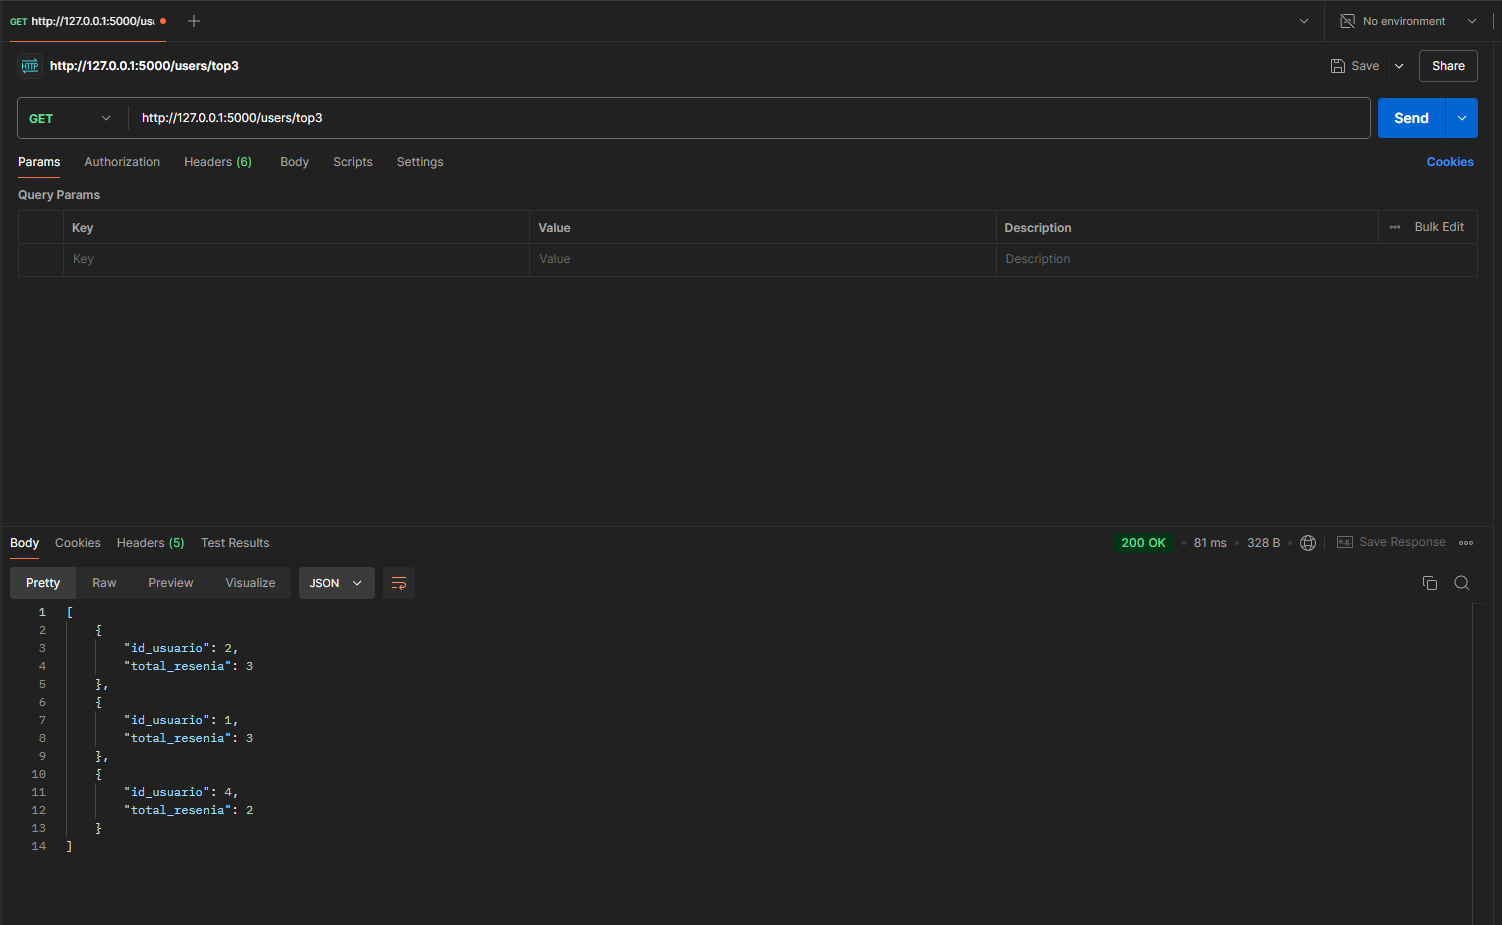

In [ ]:
#¿Cual es el metodo de pago menos utilizado en la plataforma?
@app.route('/pay-method/lessused', methods=['GET'])
def obtener_metodo_pago_menos_utilizado():
    conn = get_db_connection()
    cursor = conn.cursor()

    cursor.execute("""SELECT TOP 1 metodoDePago, COUNT(*) AS total_uso
                        FROM Pago
                        GROUP BY metodoDePago
                        ORDER BY total_uso ASC;
                        """)
    rows = cursor.fetchall()

    items = []
    for row in rows:
        items.append({"metodoDePago": row[0], "total_uso": row[1]})

    conn.close()

    return jsonify(items)

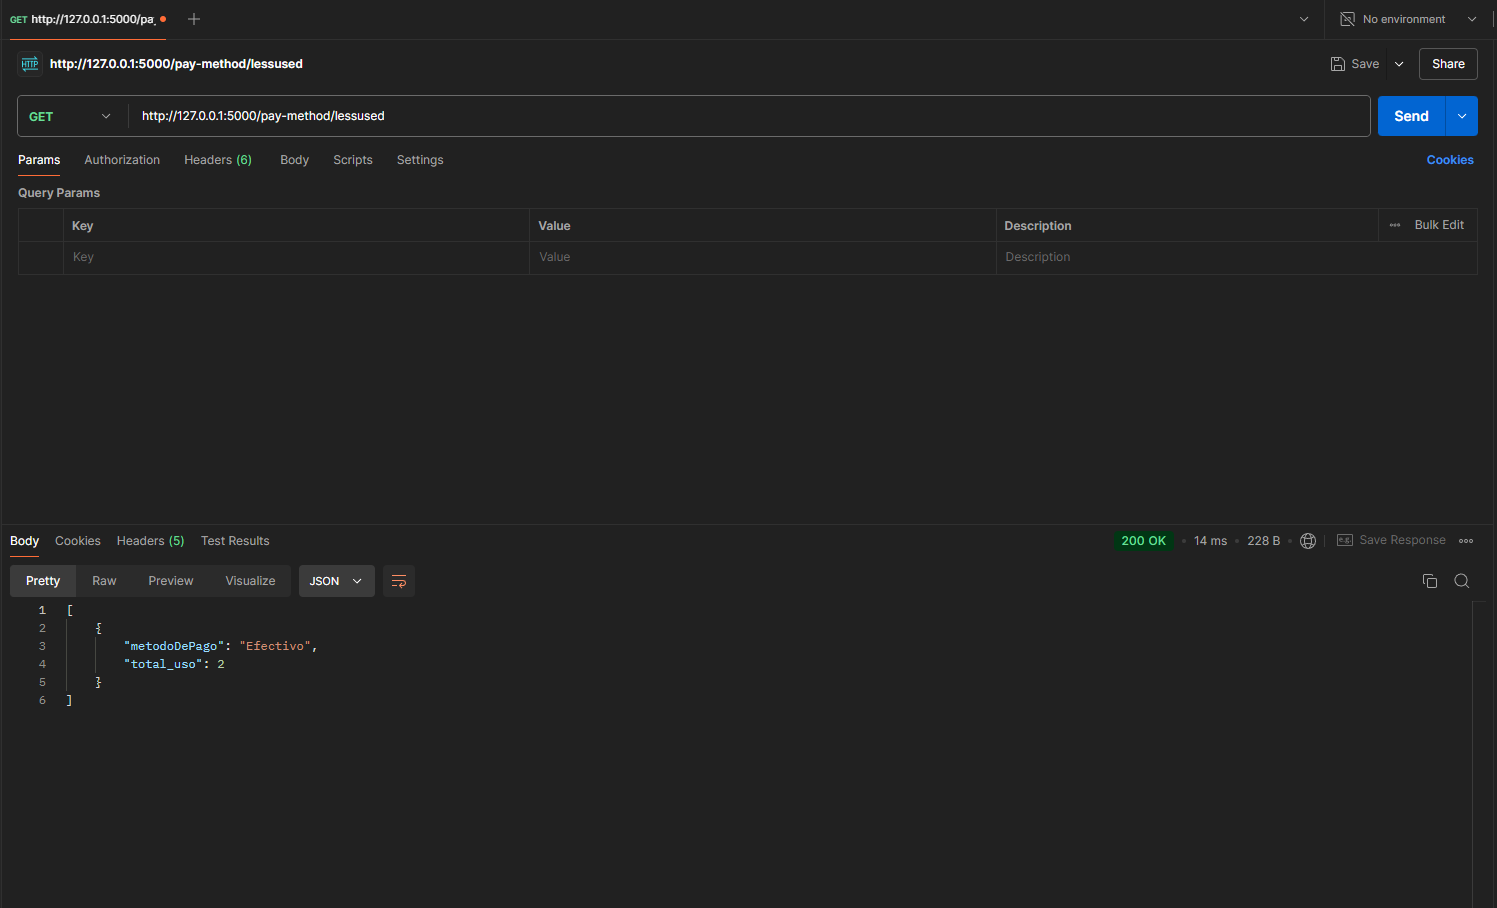

In [ ]:
#¿Cuales son los conductores que han estado inactivos en el ultimo mes? 
@app.route('/drivers/inactive', methods=['GET'])
def obtener_conductores_inactivos():
    conn = get_db_connection()
    cursor = conn.cursor()
    cursor.execute("""SELECT c.id_conductor, c.nombre
                        FROM Conductor c
                        WHERE c.id_conductor NOT IN (
                            SELECT id_conductor
                            FROM Viaje
                            WHERE fecha_hora_final >= DATEADD(DAY, -30, GETDATE()));"""
                        )
    rows = cursor.fetchall()

    items = []
    for row in rows:
        items.append({"id_conductor": row[0], "nombre": row[1]})

    conn.close()
    
    return jsonify(items)

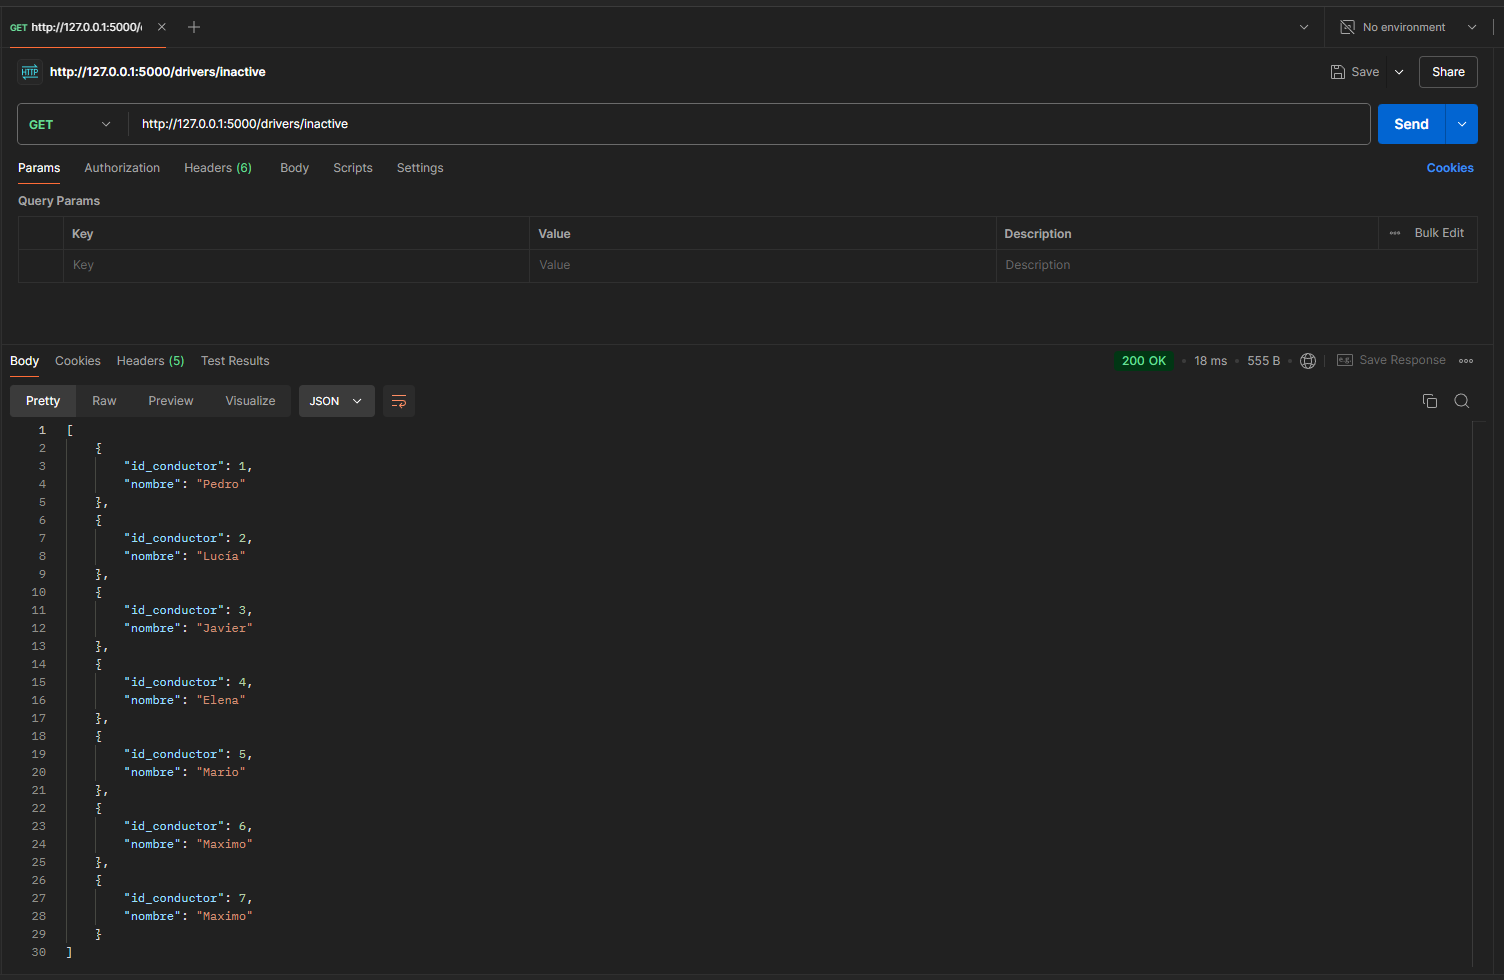

In [ ]:
#¿Que conductores y pasajeros han coincidido en mas de 1 viaje en la aplicacion? 
@app.route('/coincidencias', methods=['GET'])
def obtener_viajes_comunes():
    conn = get_db_connection()
    cursor = conn.cursor()

    cursor.execute("""SELECT 
                        v.id_conductor, v.id_usuario, COUNT(v.id_viaje) AS total_viajes 
                        FROM  Viaje v
                        GROUP BY v.id_conductor, v.id_usuario
                        HAVING COUNT(v.id_viaje) > 1;
                        """)
    rows = cursor.fetchall()

    items = []
    for row in rows:
        items.append({"id_coductor": row[0], "id_usuario": row[1], "total_viajes": row[2]})

    conn.close()
    
    return jsonify(items)

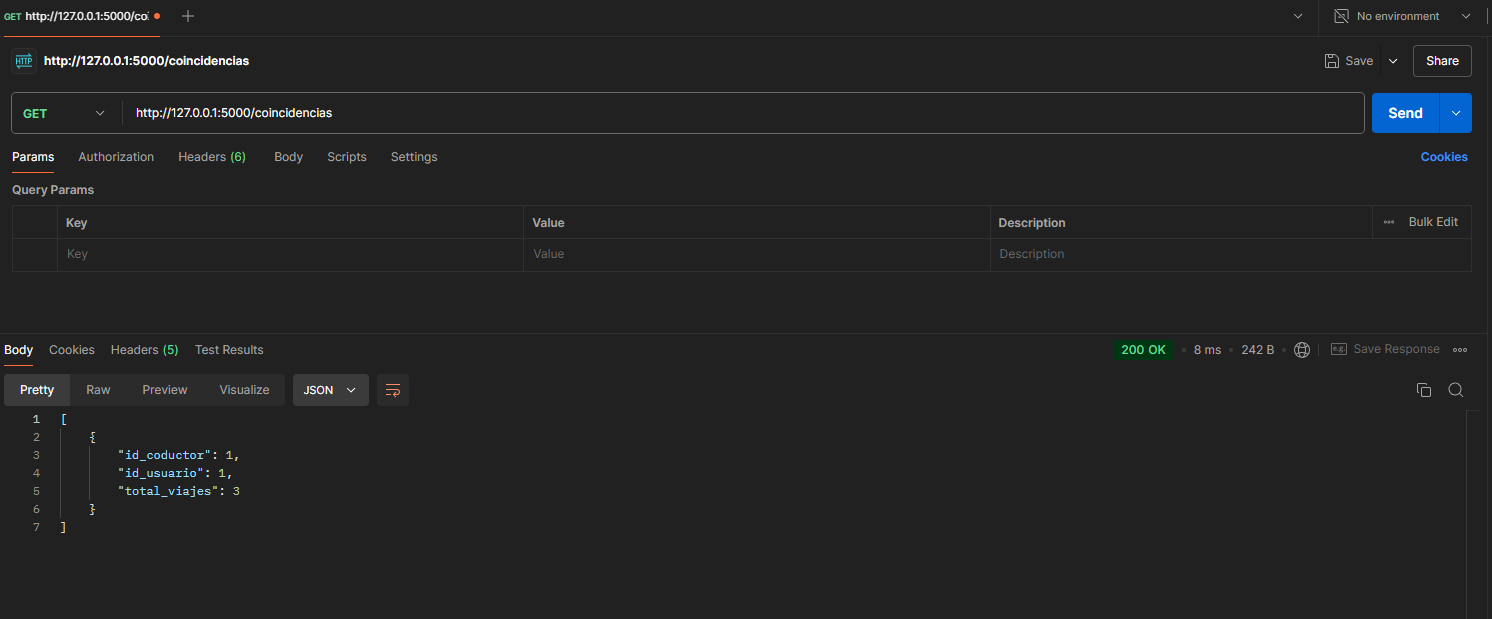

In [ ]:
#¿Cuantos autos con terminacion de patente en “D” y de Marca Toyota hay en la plataforma? 
@app.route('/cars/toyota', methods=['GET'])
def obtener_autos_toyota():
    conn = get_db_connection()
    cursor = conn.cursor()

    cursor.execute("""SELECT COUNT(*) AS total_veiculos
                        FROM Veiculo
                        WHERE marca = 'Toyota' AND patente LIKE '%D';
                        """)
    rows = cursor.fetchall()

    items = []
    for row in rows:
        items.append({"total Toyotas con D": row[0]})

    conn.close()
    
    return jsonify(items)

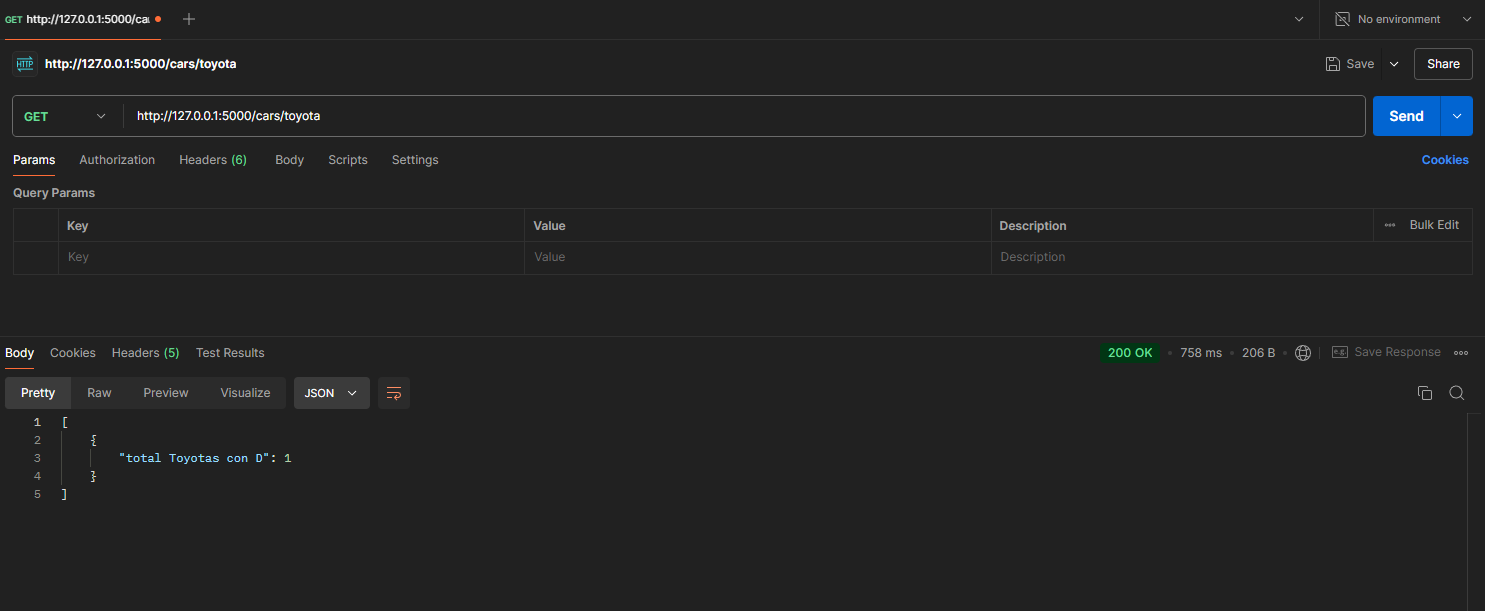

In [ ]:
#¿Cuales son los usuarios que han dado una calificacion de 5 o una calificacion menor de 2? 
@app.route('/users/fivestars', methods=['GET'])
def obtener_usuarios_calificaciones():
    conn = get_db_connection()
    cursor = conn.cursor()

    cursor.execute("""SELECT DISTINCT id_usuario
                        FROM Reseña
                        WHERE calificacion = 5 OR calificacion <= 2;
                        """)
    rows = cursor.fetchall()

    items = []
    for row in rows:
        items.append({"id_usuario": row[0]})

    conn.close()
    
    return jsonify(items)

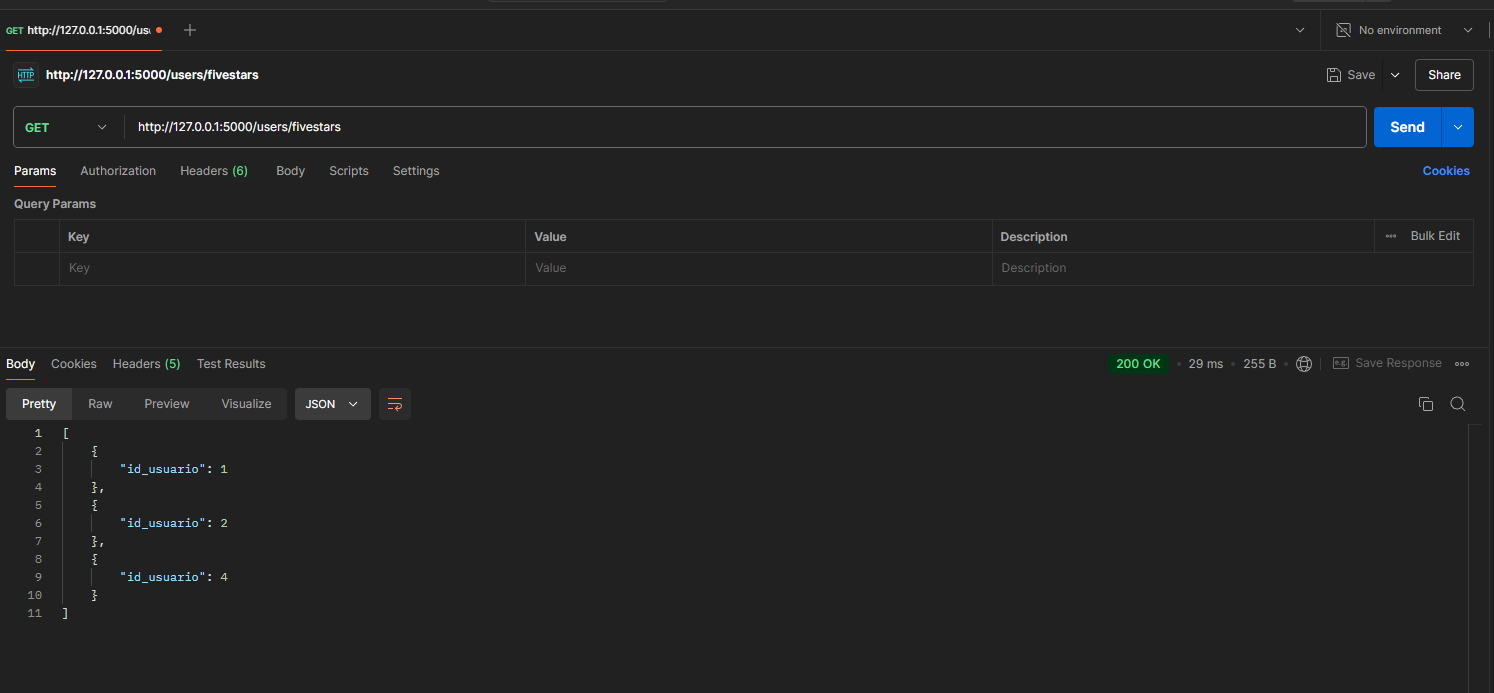

In [ ]:
#¿Cual es el tiempo promedio de los viajes? 
@app.route('/travels/avgtime', methods=['GET'])
def obtener_tiempo_promedio():
    conn = get_db_connection()
    cursor = conn.cursor()

    cursor.execute("""SELECT 
                        CONVERT(VARCHAR, DATEADD(SECOND, AVG(DATEDIFF(SECOND, '00:00:00', tiempo_viaje)), '00:00:00'), 108) AS TiempoPromedio
                        FROM Viaje;
                        """)
    rows = cursor.fetchall()

    items = []
    for row in rows:
        items.append({"Tiempo_promedio": row[0]})

    conn.close()
    
    return jsonify(items)

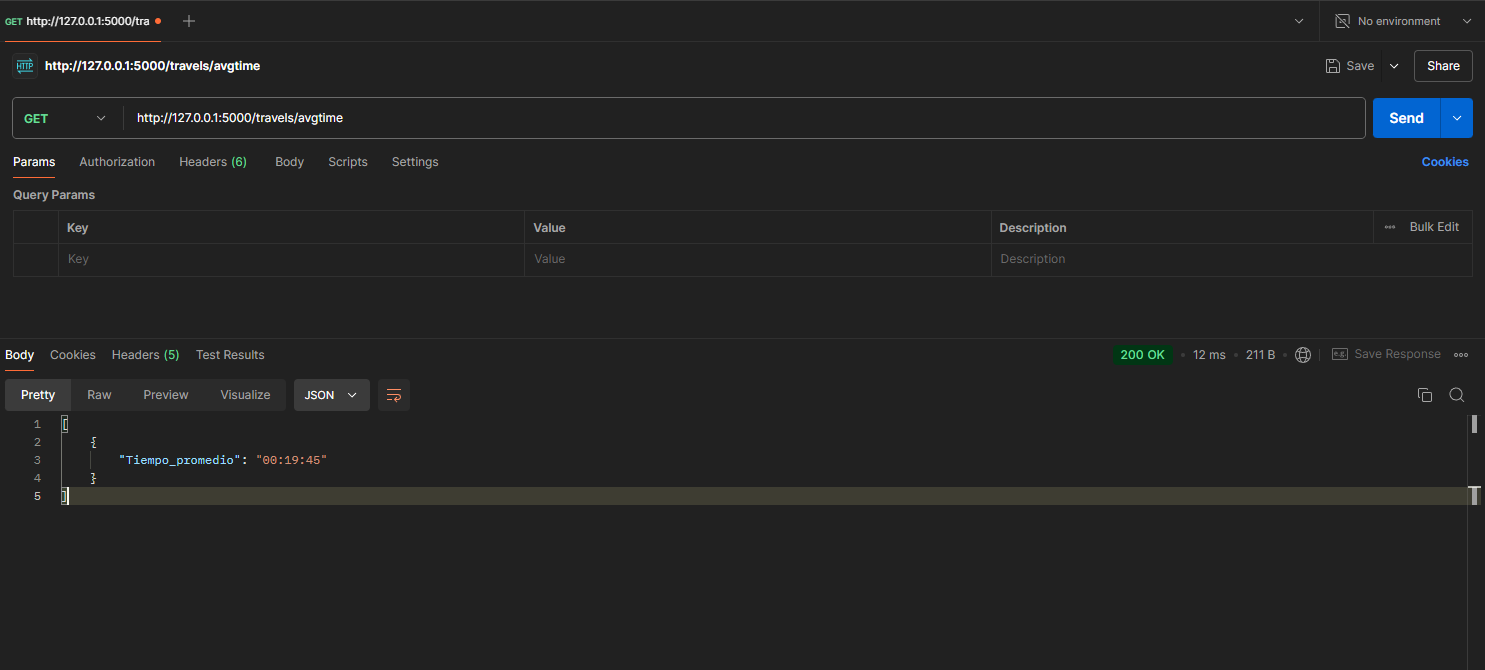